In [2]:
suppressMessages(library(ArchR))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))

In [3]:
addArchRThreads(threads = 32) 

Setting default number of Parallel threads to 32.



In [4]:
in_dir = '../../results/04_single_cell_access_atac/23_final_annotation'
out_dir = '../../results/04_single_cell_access_atac/24_trajectory_analysis'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [5]:
obj <- readRDS(glue::glue("{in_dir}/seurat_atac_obj_with_final_annotation.Rds"))

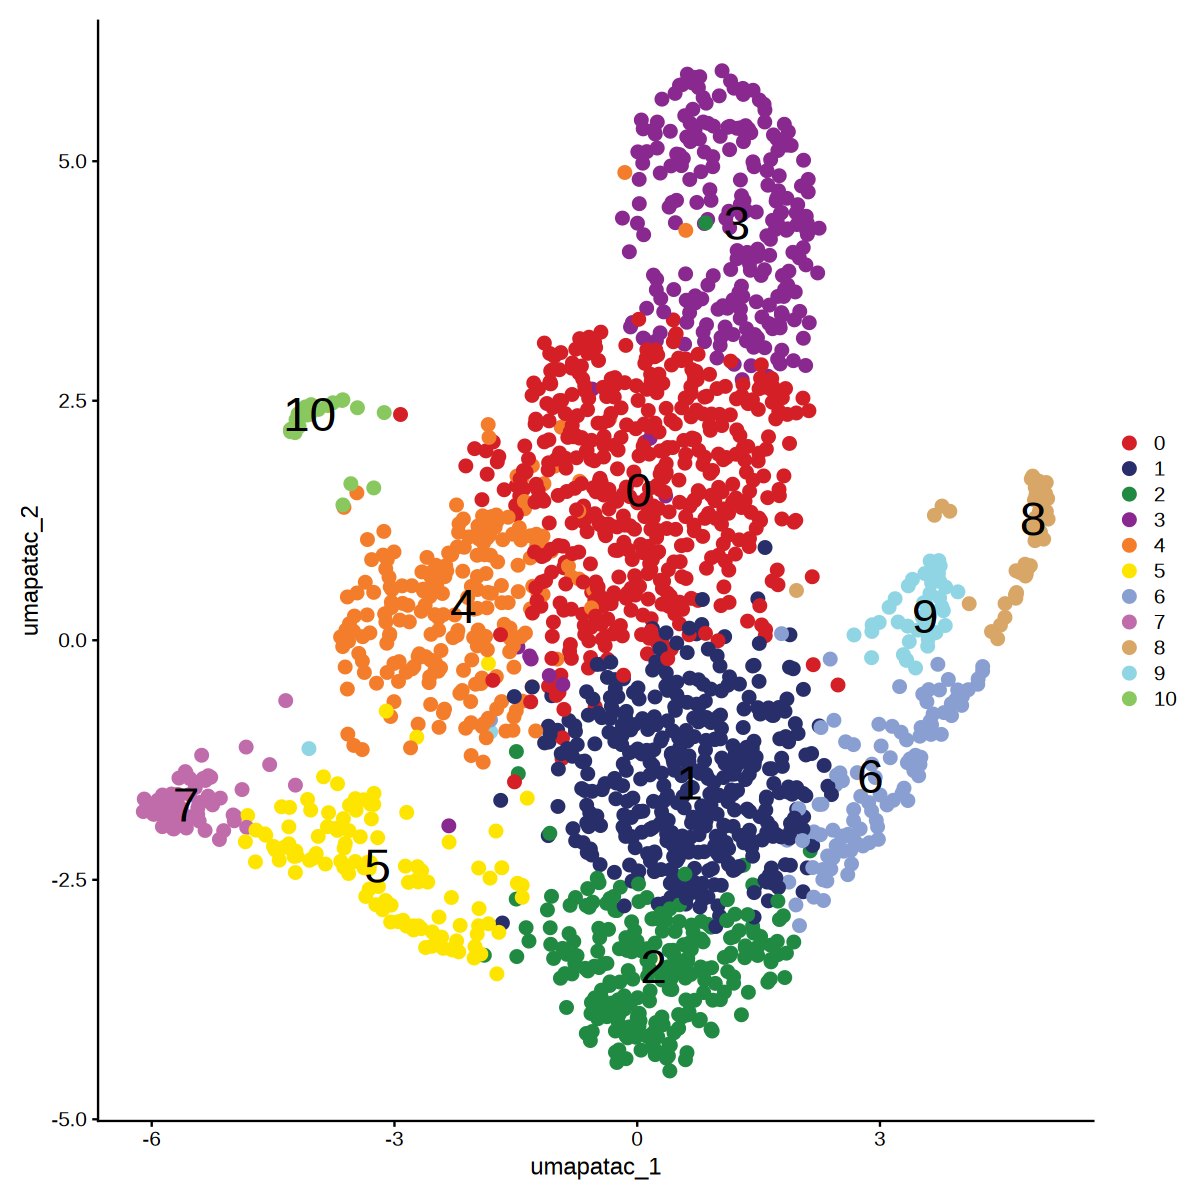

In [7]:
options(repr.plot.height = 10, repr.plot.width = 10)

p <- DimPlot(object = obj, label = TRUE, label.size = 10, pt.size = 3, 
cols = ArchR::paletteDiscrete(obj$seurat_clusters))

print(p)

In [6]:
proj <- loadArchRProject(path = "../../results/04_single_cell_access_atac/13_create_archr_project", showLogo = FALSE)

Successfully loaded ArchRProject!



In [ ]:
## add UMAP embedding
embedding <- obj@reductions$umap@cell.embeddings
embedding <- embedding[rownames(proj@cellColData), ]

colnames(embedding) <- c("LSI#UMAP_Dimension_1",
                         "LSI#UMAP_Dimension_2")

proj@embeddings[["umap"]] <- SimpleList(df = as.data.frame(embedding),
                                        params = NULL)

In [13]:
## add clusters to ArchR project
clusters <- obj@meta.data[rownames(proj@cellColData), "seurat_clusters"]

proj <- addCellColData(proj, 
                       data = as.character(clusters), 
                       name = "Clusters", 
                       cells = rownames(proj@cellColData), 
                       force = TRUE)

## add clusters to ArchR project
cell_type <- obj@meta.data[rownames(proj@cellColData), "cell_type_final"]

proj <- addCellColData(proj, 
                       data = as.character(cell_type), 
                       name = "CellType", 
                       cells = rownames(proj@cellColData), 
                       force = TRUE)

Overriding previous entry for Clusters



ArchR logging to : ArchRLogs/ArchR-plotEmbedding-1825f33f5ddcef-Date-2026-01-28_Time-20-34-50.97998.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-1825f33f5ddcef-Date-2026-01-28_Time-20-34-50.97998.log



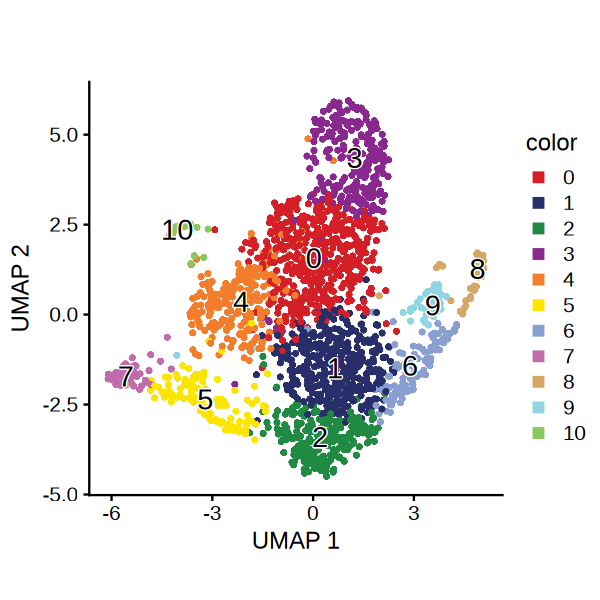

In [9]:
p <- plotEmbedding(ArchRProj = proj,
                   embedding = "umap",
                   colorBy = "cellColData",
                   name = "Clusters",
                   baseSize = 50,
                   size = 3,
                  labelSize = 6,
                  labelAsFactors = FALSE) +
    theme_cowplot() +
    xlab("UMAP 1") + ylab("UMAP 2") +
    ggtitle("")

options(repr.plot.height = 5, repr.plot.width = 5)

print(p)

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-1825f32ad1a1ec-Date-2026-01-28_Time-20-42-52.883469.log
If there is an issue, please report to github with logFile!



Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-1825f32ad1a1ec-Date-2026-01-28_Time-20-42-52.883469.log



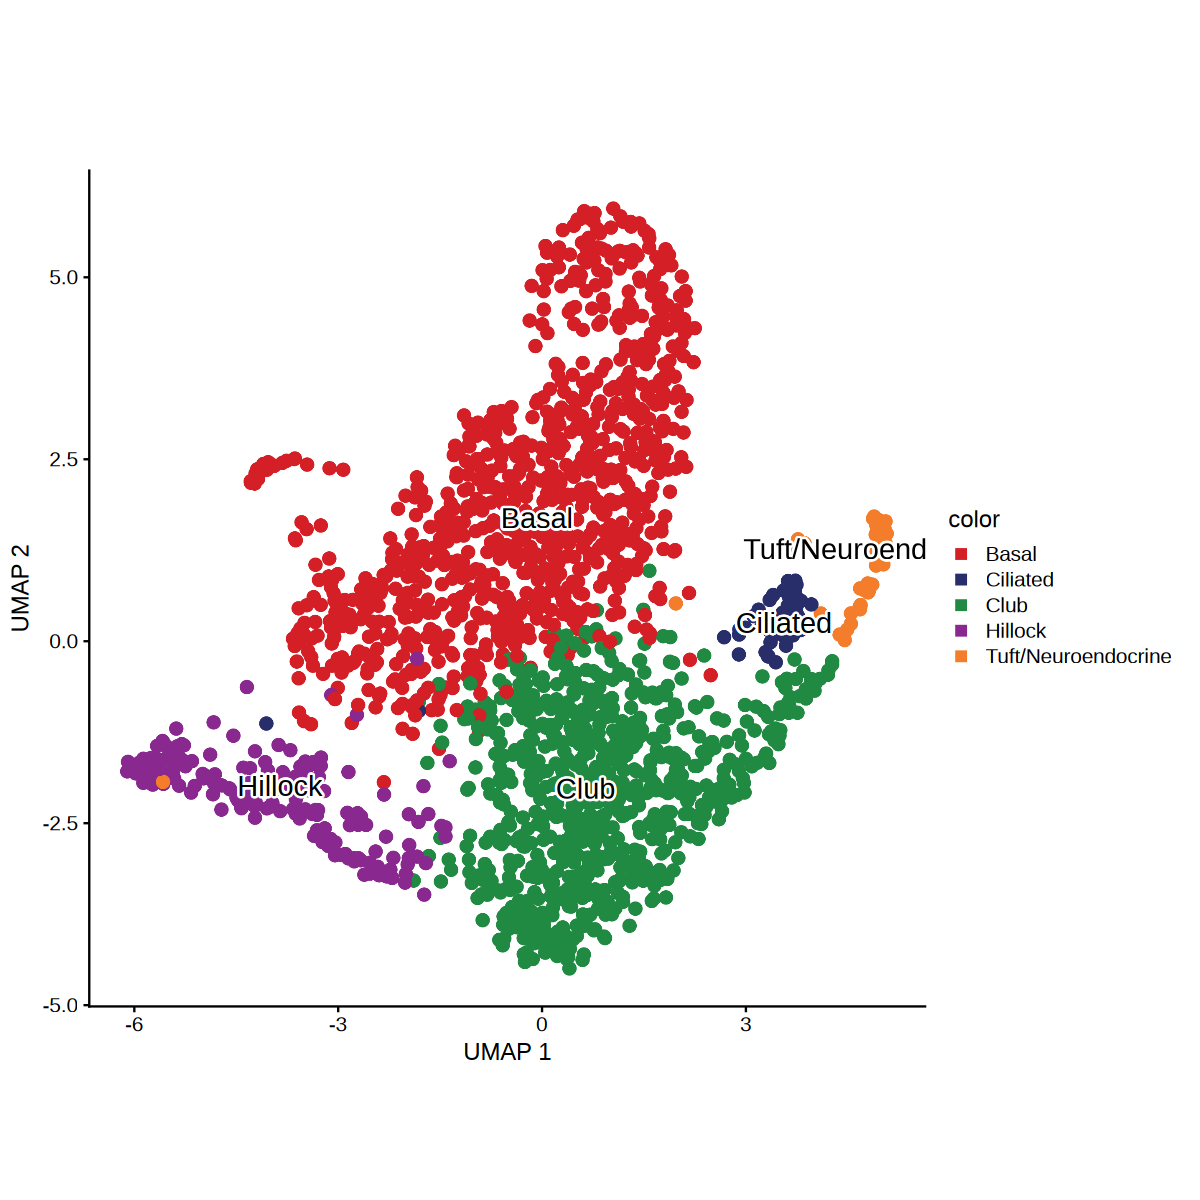

In [15]:
p <- plotEmbedding(ArchRProj = proj,
                   embedding = "umap",
                   colorBy = "cellColData",
                   name = "CellType",
                   baseSize = 50,
                   size = 3,
                  labelSize = 6,
                  labelAsFactors = FALSE) +
    theme_cowplot() +
    xlab("UMAP 1") + ylab("UMAP 2") +
    ggtitle("")

options(repr.plot.height = 10, repr.plot.width = 10)

print(p)

In [21]:
proj <- addTrajectory(
    ArchRProj = proj, 
    name = "Basal_Club", 
    groupBy = "Clusters",
    trajectory = c("3", "0", "1", "2"), 
    embedding = "umap", 
    preFilterQuantile = 0.95,
    postFilterQuantile = 0.95,
    force = TRUE,
    useAll = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addTrajectory-1825f34174ddf4-Date-2026-01-28_Time-20-45-39.921722.log
If there is an issue, please report to github with logFile!

Filtering outliers

Initial Alignment Before Spline Fit

Spline Fit



KNN to Spline

Aligning cells not in trajectory

Overriding previous entry for Basal_Club

ArchR logging successful to : ArchRLogs/ArchR-addTrajectory-1825f34174ddf4-Date-2026-01-28_Time-20-45-39.921722.log



In [32]:
p <- plotTrajectory(proj, embedding = "umap", trajectory = "Basal_Club", 
colorBy = "cellColData", name = "Basal_Club", plotAs="points", baseSize = 50,
                   size = 3,
                  labelSize = 6,
                  labelAsFactors = FALSE) 

ArchR logging to : ArchRLogs/ArchR-plotTrajectory-1825f371a28c2f-Date-2026-01-28_Time-21-10-40.2082.log
If there is an issue, please report to github with logFile!

Plotting

Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-1825f371a28c2f-Date-2026-01-28_Time-21-10-40.2082.log



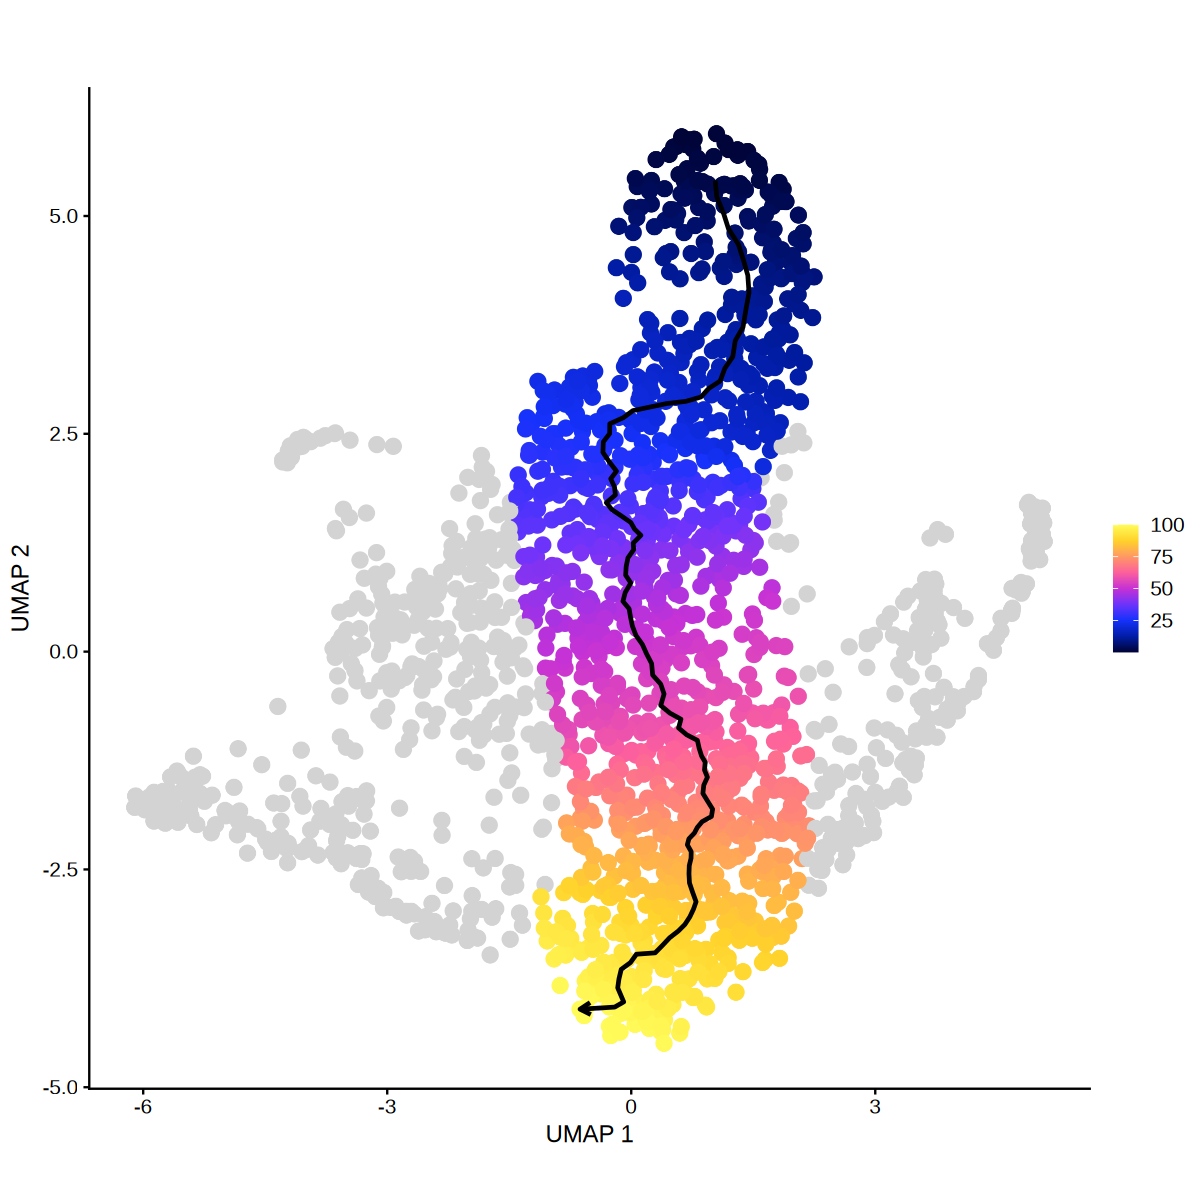

In [34]:
options(repr.plot.height = 10, repr.plot.width = 10)
p <- p[[1]] + cowplot::theme_cowplot() + xlab("UMAP 1") + ylab("UMAP 2") +
    ggtitle("")

print(p)

In [ ]:
## Save data
saveArchRProject(ArchRProj = proj, 
                 load = FALSE)

In [ ]:
## Session information
sessionInfo()